## **Análisis estadístico**

In [2]:
# Tratamiento de datos
import pandas as pd
pd.set_option('display.max_columns', None)

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import sys
sys.path.append('../')

# Cargar automáticamente los archivos src
%load_ext autoreload
%autoreload 2

#Funciones personalizadas
from src import sp_analisis as sa 

In [3]:
df = pd.read_csv("../data/data_limpios.csv")
df.sample(3)

,P1,P2,P2.1,P3,P4,P5,P6,P7,P8.1,P8.2,P8.3,P9,P10,P11.1,P11.2,P11.3,P11.4,P11.5,P11.6,P11.7,P12,P13,P14.1,P14.2,P14.3,P14.4,P14.5,P14.6,P14.7,P15,P16,P17,P18,P19,P20,P21,P22,P23,P4_categorias
99,1955,Sí,NaN,25.0,NaN,0,De nadie en particular,"Ansiedad, Depresión, Miedo, Soledad, Preocupación",2,7.0,2.0,No,Sí,Ni acuerdo ni desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente de acuerdo,En desacuerdo,En desacuerdo,35-39 años,"Precariedad laboral, Difícil emancipación, Fal...",6,6,6,6,6,5,5,"No, debería ser más",10,No,De acuerdo,Católica no practicante,3,Pensionista,De 1.100 a 1.800,Bachillerato,NaN
72,1957,Sí,NaN,33.0,NaN,0,De nadie en particular,Preocupación,0,10.0,10.0,No,No,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente de acuerdo,Ni acuerdo ni desacuerdo,Totalmente de acuerdo,40 o más años,"Precariedad laboral, Difícil emancipación, Fal...",7,7,7,5,5,5,7,Sí,10,No,Totalmente de acuerdo,No creyente,1,Pensionista,De 1.100 a 1.800,Estudios universitarios o equivalentes,NaN
185,1990,Sí,NaN,21.0,NaN,3,De nadie en particular,Preocupación,6,6.0,6.0,Sí,Sí,Totalmente de acuerdo,Ni acuerdo ni desacuerdo,En desacuerdo,Ni acuerdo ni desacuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Ni acuerdo ni desacuerdo,40 o más años,"Precariedad laboral, Falta de estabilidad econ...",7,7,7,7,7,7,7,"No, debería ser más",10,Sí,Totalmente de acuerdo,Católica no practicante,5,"Trabajadores de servicios de restauración, per...",De 1.100 a 1.800,Estudios primarios o equivalentes,NaN


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
P1,231.0,1983.337662,14.220570,1950.0,1970.0,1987.0,1996.00,2005.0
P3,134.0,28.664179,5.416411,16.0,25.0,29.0,32.75,41.0
P5,231.0,2.662338,3.112152,0.0,0.0,1.0,5.00,10.0
P8.1,231.0,4.428571,3.652618,0.0,1.0,3.0,8.00,10.0
P8.2,226.0,3.681416,3.014824,0.0,1.0,3.0,6.00,10.0
P8.3,218.0,3.738532,3.292287,0.0,1.0,2.0,6.00,10.0
P14.1,231.0,6.419913,1.000583,1.0,6.0,7.0,7.00,7.0
P14.2,231.0,6.523810,0.843438,2.0,6.0,7.0,7.00,7.0
P14.3,231.0,6.303030,1.081038,1.0,6.0,7.0,7.00,7.0
P14.4,231.0,6.064935,1.142130,1.0,5.0,6.0,7.00,7.0


In [7]:
df['P20'] = pd.to_numeric(df['P20'], errors='coerce')

df['ideologia_agrupada'] = 'N.C.'
# Izquierda
df.loc[df['P20'] <= 3, 'ideologia_agrupada'] = 'Izquierda'
# Centro
df.loc[(df['P20'] >=4) & (df['P20'] <=6), 'ideologia_agrupada'] = 'Centro'
'Derecha'
df.loc[df['P20'] >= 7, 'ideologia_agrupada'] = 'Derecha'

print(df['ideologia_agrupada'].value_counts())

ideologia_agrupada
Izquierda    111
Centro        93
Derecha       27
Name: count, dtype: int64


In [5]:
percepcion = ['P8.1', 'P8.2', 'P8.3']

In [6]:
sa.normalidad(df, percepcion)

Los datos de P8.1 NO siguen una distribución normal
Los datos de P8.2 NO siguen una distribución normal
Los datos de P8.3 NO siguen una distribución normal


In [8]:
sa.homocedasticidad(df, 'ideologia_agrupada', percepcion)

Para la columna P8.1 las varianzas no son homogéneas entre grupos, es decir, NO hay homocedasticidad
Para la columna P8.2 las varianzas no son homogéneas entre grupos, es decir, NO hay homocedasticidad
Para la columna P8.3 las varianzas no son homogéneas entre grupos, es decir, NO hay homocedasticidad


In [9]:
sa.mannwhitneyu(df, 'ideologia_agrupada', percepcion)

Para la métrica P8.1, las medianas no son iguales, es decir, SI hay diferencias significativas entre los grupos
Para la métrica P8.2, las medianas no son iguales, es decir, SI hay diferencias significativas entre los grupos
Para la métrica P8.3, las medianas no son iguales, es decir, SI hay diferencias significativas entre los grupos


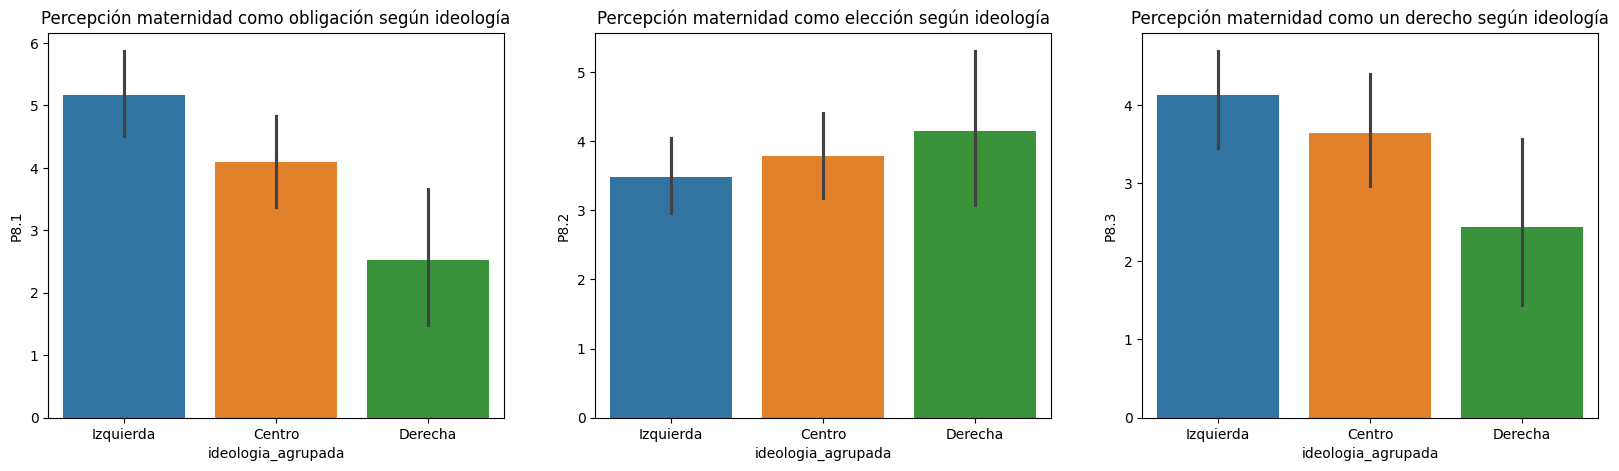

In [10]:
fi, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

sns.barplot(x='ideologia_agrupada', y='P8.1', hue='ideologia_agrupada', data=df, ax = axes[0])
axes[0].set_title('Percepción maternidad como obligación según ideología')
sns.barplot(x='ideologia_agrupada', y='P8.2', hue='ideologia_agrupada', data=df, ax = axes[1])
axes[1].set_title('Percepción maternidad como elección según ideología')
sns.barplot(x='ideologia_agrupada', y='P8.3', hue='ideologia_agrupada', data=df, ax = axes[2])
axes[2].set_title('Percepción maternidad como un derecho según ideología');
